In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_parquet('../data/processed/train_features.parquet')

print(f"Загружено строк: {len(df):,}")

Загружено строк: 40,618,962


Нам нужно оставить только те колонки, которые реально помогают предсказывать.


Мы оставляем только те данные, которые известны нам в момент рекомендации, до того как пользователь нажал кнопку «Play». Это те самые характеристики, которые помогут модели догадаться, какой будет досмотр.

In [4]:
# Список колонок, которые мы НЕ берем в модель (таргет, ID и технические утечки)
drop_cols = [
    'user_id', 'item_id', 'author_id',
    'target', 'timespent',
    'train_interactions_rank_x', 'train_interactions_rank_y', # служебный мусор
    'author_mean_target', 'user_mean_target' # Дубликаты (у тебя в коде используются аналогичные avg-версии)
]

# Все остальные колонки (включая als_score, engagement_score, video_duration_type) идут в обучение
features = [c for c in df.columns if c not in drop_cols]

print(f"Используем {len(features)} признаков для обучения.")
print("Список признаков:", features)

Используем 25 признаков для обучения.
Список признаков: ['place', 'platform', 'agent', 'like', 'dislike', 'share', 'bookmark', 'click_on_author', 'open_comments', 'duration', 'age', 'gender', 'geo', 'author_video_count', 'user_watch_count', 'engagement_score', 'author_avg_target', 'author_avg_engagement', 'author_popularity', 'user_avg_target', 'user_avg_engagement', 'user_activity', 'video_duration_type', 'als_score', 'embedding_similarity_score']


берем 5 миллионов строк и делим их на 80% (обучение) и 20% (проверка)

In [5]:
from sklearn.model_selection import train_test_split
import gc

df_sample = df.sample(n=5000000, random_state=42)

X = df_sample[features]
y = df_sample['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Сэмпл для безопасного перебора параметров
X_tune = X_train.sample(n=200000, random_state=42)
y_tune = y_train.sample(n=200000, random_state=42)

# Удаляем df_sample чтоб освободить RAM
del df_sample
gc.collect()

print(f"Обучающая выборка: {X_train.shape[0]:,} строк")
print(f"Тестовая выборка: {X_test.shape[0]:,} строк")
print(f"Выборка для тюнинга параметров: {X_tune.shape[0]:,} строк")

Обучающая выборка: 4,000,000 строк
Тестовая выборка: 1,000,000 строк
Выборка для тюнинга параметров: 200,000 строк


Обоснование корректности разбиения (Валидация без Data Leakage)

В рамках рекомендательных систем пересечение `user_id` и `item_id` между train и test выборками **не является утечкой данных (Data Leakage)**, а отражает стандартную схему работы алгоритмов коллаборативной фильтрации.

Мы решаем задачу рекомендации для *уже известных* системе пользователей на основе их накопленной истории взаимодействий. Если бы мы полностью разносили пользователей по разным выборкам (Out-of-User Split), мы бы тестировали модель в режиме холодного старта (Cold Start), что не является целевой задачей данной архитектуры.

Как мы избежали реального Data Leakage:

1.  Удалили из признаков (`drop_cols`) прямые таргет-статистики (`author_mean_target`, `user_mean_target`), рассчитанные по всему датасету.
2. Векторные профили пользователей и эмбеддинги собирались на основе исторических (прошлых) признаков взаимодействия, а не текущего предсказываемого таргета.

Baseline — Линейная Регрессия

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_base = model_lr.predict(X_test)
y_pred_base = np.clip(y_pred_base, 0, 1)

mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print(f"LINEAR REGRESSION РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_base:.4f}")
print(f"MSE:  {mse_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")
print(f"R2:   {r2_base:.4f}")

LINEAR REGRESSION РЕЗУЛЬТАТЫ
MAE:  0.3088
MSE:  0.1257
RMSE: 0.3546
R2:   0.2441


In [7]:
import joblib

model_path_lr = '../models/linear_regression_v1.pkl'
joblib.dump(model_lr, model_path_lr)

print(f"Модель Baseline сохранена по пути: {model_path_lr}")

Модель Baseline сохранена по пути: ../models/linear_regression_v1.pkl


Цифра MAE: 0.3088 говорит нам о том, что в среднем простая линейная модель ошибается на 30% при предсказании досмотра видео.

LightGBM

In [8]:
!pip install lightgbm


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("1. Подбор гиперпараметров для LightGBM...")
lgb_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63]
}

lgb_search = RandomizedSearchCV(
    estimator=LGBMRegressor(objective='regression_l1', random_state=42, n_jobs=-1),
    param_distributions=lgb_grid,
    n_iter=3,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_tune, y_tune)
print(f"Лучшие параметры LightGBM: {lgb_search.best_params_}")

print("\n2. Обучение финального LightGBM на всех данных с лоссом MAE...")
lgb_params = lgb_search.best_params_
lgb_params['objective'] = 'regression_l1'
lgb_params['importance_type'] = 'gain'

lgb_model = LGBMRegressor(**lgb_params, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='mae')

y_pred_lgb = np.clip(lgb_model.predict(X_test), 0, 1)

mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"\nLIGHTGBM РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_lgb:.4f}")
print(f"MSE:  {mse_lgb:.4f}")
print(f"RMSE: {rmse_lgb:.4f}")
print(f"R2:   {r2_lgb:.4f}")

improvement = ((mae_base - mae_lgb) / mae_base) * 100
print(f"Улучшение MAE к Baseline (Linear Regression): {improvement:.2f}%")

1. Подбор гиперпараметров для LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2919
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 25
[LightGBM] [Info] Start training from score 0.478932
Лучшие параметры LightGBM: {'num_leaves': 63, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05}

2. Обучение финального LightGBM на всех данных с лоссом MAE...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2921
[LightGBM] [Info] Number of data points in the train set: 4000000, number of used features: 25
[LightGBM] [Info] Start training from score 0.481481

LIGHTGBM РЕЗУЛЬТАТЫ
MAE:  0.2749
MS

узнаем, на что модель опиралась при принятии решений.

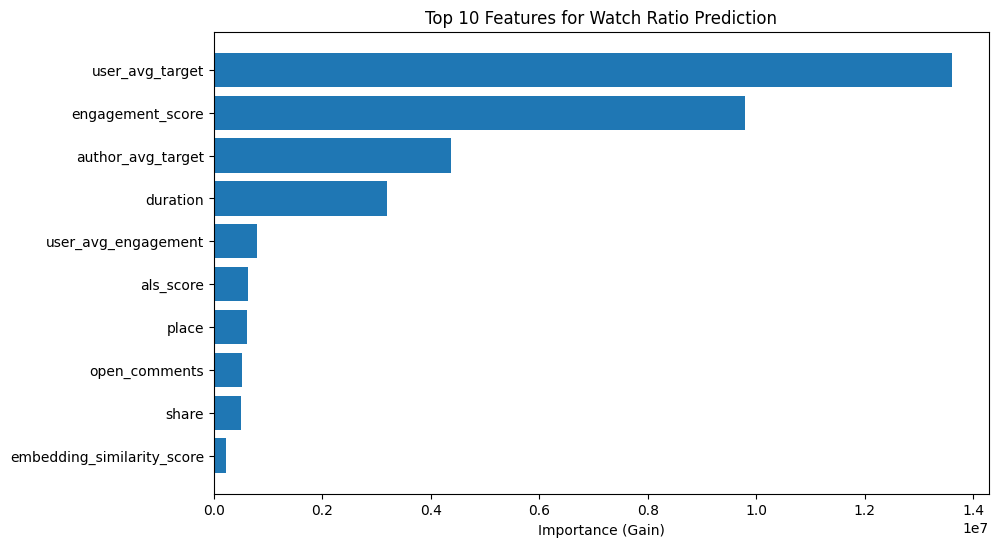

Топ-5 самых важных признаков:
                feature    importance
19      user_avg_target  1.360618e+07
15     engagement_score  9.798683e+06
16    author_avg_target  4.372252e+06
9              duration  3.196898e+06
20  user_avg_engagement  8.020824e+05


In [10]:
importances = pd.DataFrame({
    'feature': features,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'][:10], importances['importance'][:10])
plt.xlabel('Importance (Gain)')
plt.title('Top 10 Features for Watch Ratio Prediction')
plt.gca().invert_yaxis()
plt.show()

print("Топ-5 самых важных признаков:")
print(importances.head(5))

Модель поняла самое главное — зритель важнее контента. Если человек привык досматривать видео до конца, он, скорее всего, досмотрит и это. Это мощнейший признак, который тащит на себе весь прогноз.

Помимо всего этого в топе у нас:

Качество автора и длина ролика

Наш созданный признак engagment_score вошел тоже в топ - это значит что модель активно использует лайки/репосты для уточнения прогноза.


In [11]:
model_path = '../models/lightgbm_v1.pkl'
joblib.dump(lgb_model, model_path)

print(f"Модель сохранена по пути: {model_path}")

Модель сохранена по пути: ../models/lightgbm_v1.pkl


XGBoost

In [12]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("1. Подбор гиперпараметров для XGBoost...")
xgb_grid = {
    'n_estimators': [100, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:absoluteerror', tree_method='hist', random_state=42, n_jobs=-1),
    param_distributions=xgb_grid,
    n_iter=2,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_tune, y_tune)
print(f"Лучшие параметры XGBoost: {xgb_search.best_params_}")

print("\n2. Обучение финального XGBoost на всех данных с лоссом MAE...")
xgb_params = xgb_search.best_params_
xgb_params['objective'] = 'reg:absoluteerror'
xgb_params['tree_method'] = 'hist'

xgb_model = XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, 1)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBOOST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_xgb:.4f}")
print(f"MSE:  {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2:   {r2_xgb:.4f}")

1. Подбор гиперпараметров для XGBoost...
Лучшие параметры XGBoost: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}

2. Обучение финального XGBoost на всех данных с лоссом MAE...

XGBOOST РЕЗУЛЬТАТЫ
MAE:  0.2755
MSE:  0.1388
RMSE: 0.3726
R2:   0.1652


In [14]:
model_path_xgb = '../models/xgboost_v1.pkl'
joblib.dump(xgb_model, model_path_xgb)

print(f"Модель XGBoost сохранена по пути: {model_path_xgb}")

Модель XGBoost сохранена по пути: ../models/xgboost_v1.pkl


CatBoost

In [15]:
!pip install catboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("1. Подбор гиперпараметров для CatBoost...")
cat_grid = {
    'iterations': [100, 300],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(loss_function='MAE', random_state=42, silent=True, thread_count=-1),
    param_distributions=cat_grid,
    n_iter=2,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=1 # Для стабильности потоков CatBoost внутри sklearn
)
cat_search.fit(X_tune, y_tune)
print(f"Лучшие параметры CatBoost: {cat_search.best_params_}")

print("\n2. Обучение финального CatBoost на всех данных с лоссом MAE...")
cat_params = cat_search.best_params_
cat_params['loss_function'] = 'MAE'

cat_model = CatBoostRegressor(**cat_params, random_state=42, silent=True, thread_count=-1)
cat_model.fit(X_train, y_train)

y_pred_cat = np.clip(cat_model.predict(X_test), 0, 1)

mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print(f"\nCATBOOST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_cat:.4f}")
print(f"MSE:  {mse_cat:.4f}")
print(f"RMSE: {rmse_cat:.4f}")
print(f"R2:   {r2_cat:.4f}")

1. Подбор гиперпараметров для CatBoost...
Лучшие параметры CatBoost: {'learning_rate': 0.1, 'iterations': 100, 'depth': 8}

2. Обучение финального CatBoost на всех данных с лоссом MAE...

CATBOOST РЕЗУЛЬТАТЫ
MAE:  0.2779
MSE:  0.1413
RMSE: 0.3759
R2:   0.1502


In [17]:
model_path_cat = '../models/catboost_v1.pkl'
joblib.dump(cat_model, model_path_cat)

print(f"Модель CatBoost сохранена по пути: {model_path_cat}")

Модель CatBoost сохранена по пути: ../models/catboost_v1.pkl


Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("1. Подбор гиперпараметров для Random Forest...")
rf_grid = {
    'n_estimators': [20, 40],
    'max_depth': [6, 10]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(criterion='absolute_error', random_state=42, n_jobs=-1),
    param_distributions=rf_grid,
    n_iter=2,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_tune, y_tune)
print(f"Лучшие параметры Random Forest: {rf_search.best_params_}")

print("\n2. Обучение финального Random Forest на ограниченной выборке с критерием MAE...")
rf_params = rf_search.best_params_
rf_params['criterion'] = 'absolute_error'

# Используем X_tune вместо X_train, чтобы твой ПК не завис на финальном MAE-лесе (он очень тяжелый)
rf_model = RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1)
rf_model.fit(X_tune, y_tune)

y_pred_rf = np.clip(rf_model.predict(X_test), 0, 1)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRANDOM FOREST РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

# --- ВАЖНО: В самом конце удаляем наш временный сэмпл для очистки RAM ---
import gc
del X_tune, y_tune
gc.collect()

1. Подбор гиперпараметров для Random Forest...
Лучшие параметры Random Forest: {'n_estimators': 40, 'max_depth': 10}

2. Обучение финального Random Forest на ограниченной выборке с критерием MAE...

RANDOM FOREST РЕЗУЛЬТАТЫ
MAE:  0.2797
MSE:  0.1471
RMSE: 0.3835
R2:   0.1157


5681

In [19]:
model_path_rf = '../models/random_forest_v1.pkl'
joblib.dump(rf_model, model_path_rf)

print(f"Модель Random Forest сохранена по пути: {model_path_rf}")

Модель Random Forest сохранена по пути: ../models/random_forest_v1.pkl


Ансамбль (LGBM + XGB + Cat)

In [20]:
print("Создание ансамбля (LGBM + XGB + Cat)")
y_pred_ensemble = (y_pred_lgb + y_pred_xgb + y_pred_cat) / 3

mae_ens = mean_absolute_error(y_test, y_pred_ensemble)
mse_ens = mean_squared_error(y_test, y_pred_ensemble)
rmse_ens = np.sqrt(mse_ens)
r2_ens = r2_score(y_test, y_pred_ensemble)

print(f"\nENSEMBLE РЕЗУЛЬТАТЫ")
print(f"MAE:  {mae_ens:.4f}")
print(f"MSE:  {mse_ens:.4f}")
print(f"RMSE: {rmse_ens:.4f}")
print(f"R2:   {r2_ens:.4f}")

Создание ансамбля (LGBM + XGB + Cat)

ENSEMBLE РЕЗУЛЬТАТЫ
MAE:  0.2755
MSE:  0.1395
RMSE: 0.3735
R2:   0.1614


Сделаем общий вывод

In [21]:
import pandas as pd

final_data = [
    {
        'Model': 'Linear Regression (Baseline)',
        'MAE': mae_base,
        'MSE': mse_base,
        'RMSE': rmse_base,
        'R2': r2_base
    },
    {
        'Model': 'Random Forest',
        'MAE': mae_rf,
        'MSE': mse_rf,
        'RMSE': rmse_rf,
        'R2': r2_rf
    },
    {
        'Model': 'XGBoost',
        'MAE': mae_xgb,
        'MSE': mse_xgb,
        'RMSE': rmse_xgb,
        'R2': r2_xgb
    },
    {
        'Model': 'CatBoost',
        'MAE': mae_cat,
        'MSE': mse_cat,
        'RMSE': rmse_cat,
        'R2': r2_cat
    },
    {
        'Model': 'LightGBM',
        'MAE': mae_lgb,
        'MSE': mse_lgb,
        'RMSE': rmse_lgb,
        'R2': r2_lgb
    },
    {
        'Model': 'Ensemble (LGBM+XGB+Cat)',
        'MAE': mae_ens,
        'MSE': mse_ens,
        'RMSE': rmse_ens,
        'R2': r2_ens
    }
]


df_results = pd.DataFrame(final_data)
baseline_mae_val = df_results.loc[df_results['Model'] == 'Linear Regression (Baseline)', 'MAE'].values[0]

df_results['Improvement %'] = ((baseline_mae_val - df_results['MAE']) / baseline_mae_val * 100).round(2)

df_results = df_results.sort_values(by='MAE').reset_index(drop=True)

print("ФИНАЛЬНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
display(df_results)

df_results.to_csv('../data/processed/model_comparison.csv', index=False)

ФИНАЛЬНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ


,Model,MAE,MSE,RMSE,R2,Improvement %
0,LightGBM,0.274913,0.140897,0.375363,0.152849,10.98
1,Ensemble (LGBM+XGB+Cat),0.275500,0.139471,0.373458,0.161425,10.79
2,XGBoost,0.275524,0.138840,0.372612,0.165221,10.78
3,CatBoost,0.277901,0.141337,0.375948,0.150206,10.01
4,Random Forest,0.279735,0.147078,0.383508,0.115685,9.41
5,Linear Regression (Baseline),0.308808,0.125727,0.354579,0.244064,0.00


Для дальнейшего тестирования выгрузим наши данные 5 лямов для тестов

In [22]:
X_test.to_parquet('../data/future_testing/X_test_final.parquet')
pd.DataFrame(y_test).to_parquet('../data/future_testing/y_test_final.parquet')